In [1]:
from analyse_TMS import ProtocoleAnalysis
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
import nibabel as nib
sys.path.append(str(Path.cwd().parent / "analysis"))

In [2]:
# ─── Study id ─────────────────
study_id = "addicott2024"
p = ProtocoleAnalysis(study_id=study_id)

In [ ]:
# ── Region Stats ────────────────────────────────────────────────────
n     = 30
stats = p.region_stats()

# ── Print number of tetrahedra per region ─────────────────────────────────────
sorted_by_elements = sorted(stats.items(), key=lambda x: x[1]["n_elements"], reverse=True)
print(f"{'Region':<10} {'N Elements':>12} {'Volume (mm³)':>15}")
print("-" * 40)
total = 0
for r, s in sorted_by_elements:
    total += s['n_elements']
    print(f"{r:<10} {s['n_elements']:>12} {s['volume_mm3']:>15.2f}")
print(total)
# ── Histogram of top N regions by volume ──────────────────────────────────────
sorted_by_volume = sorted(stats.items(), key=lambda x: x[1]["volume_mm3"], reverse=True)[:n]
labels = [str(r[0]) for r in sorted_by_volume]
values = [r[1]["volume_mm3"] for r in sorted_by_volume]

n_label = "All" if n == "all" else n
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values, color="steelblue")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel("Region (atlas label)")
ax.set_ylabel("Volume (mm³)")
ax.set_title(f"Top {n_label} Regions by Volume | {study_id}")
plt.tight_layout()
plt.show()

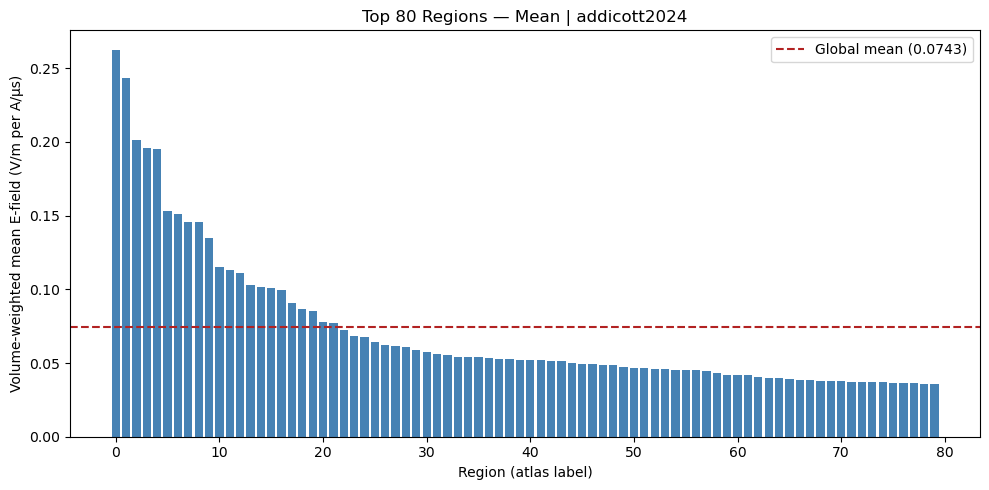

In [56]:
# ──— Volume-weighted mean by region ────────────────────────────────
n = 80
top  = p.rank_regions(n=n, metric="mean")
region_ids = [r[0] for r in top]
values     = [r[1] for r in top]
labels     = p.get_labels_for_regions(region_ids)

if n >= 50:
    labels = range(len(labels))

# moyenne globale pondérée par volume
global_mean = np.average(p.magnE, weights=p.vols)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values, color="steelblue")
ax.axhline(y=global_mean, color="firebrick", linestyle="--", 
           linewidth=1.5, label=f"Global mean ({global_mean:.4f})")
if n <= 50:
    ax.set_xticks(labels)
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Region (atlas label)")
ax.set_ylabel("Volume-weighted mean E-field (V/m per A/µs)")
ax.set_title(f"Top {n} Regions — Mean | {study_id}")
ax.legend()
plt.tight_layout()
plt.show()

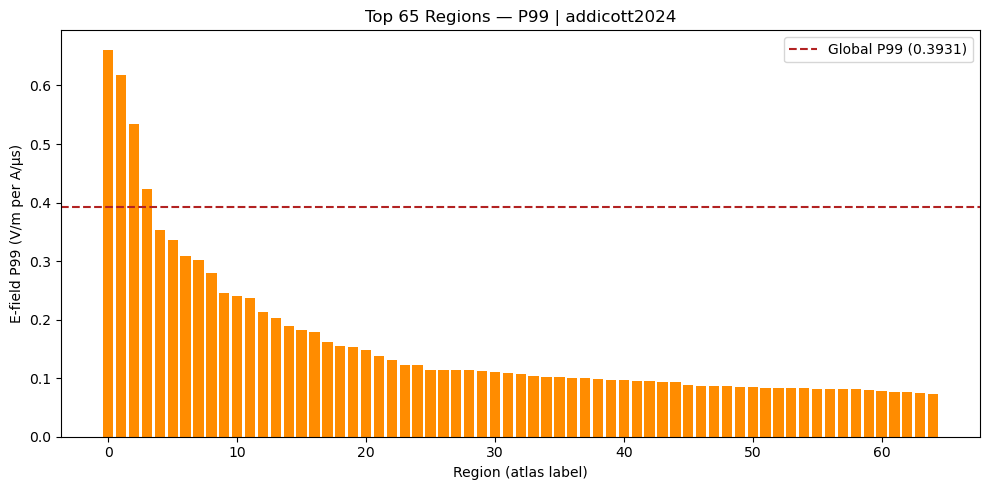

In [54]:
# ──— P95 by region ─────────────────────────────────────────────────
n = 65
percentile=99

top    = p.rank_regions(n=n, metric="percentile", percentile=percentile)
region_ids = [r[0] for r in top]
values     = [r[1] for r in top]
labels     = p.get_labels_for_regions(region_ids)

global_pct = np.percentile(p.magnE, percentile)

if n >= 50:
    labels = range(len(labels))

n_label = "All" if n == "all" else n
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, values, color="darkorange")
ax.axhline(y=global_pct, color="firebrick", linestyle="--",
           linewidth=1.5, label=f"Global P{percentile} ({global_pct:.4f})")
if n <= 50:
    ax.set_xticks(labels)
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Region (atlas label)")
ax.set_ylabel(f"E-field P{percentile} (V/m per A/µs)")
ax.set_title(f"Top {n_label} Regions — P{percentile} | {study_id}")
ax.legend()
plt.tight_layout()
plt.show()

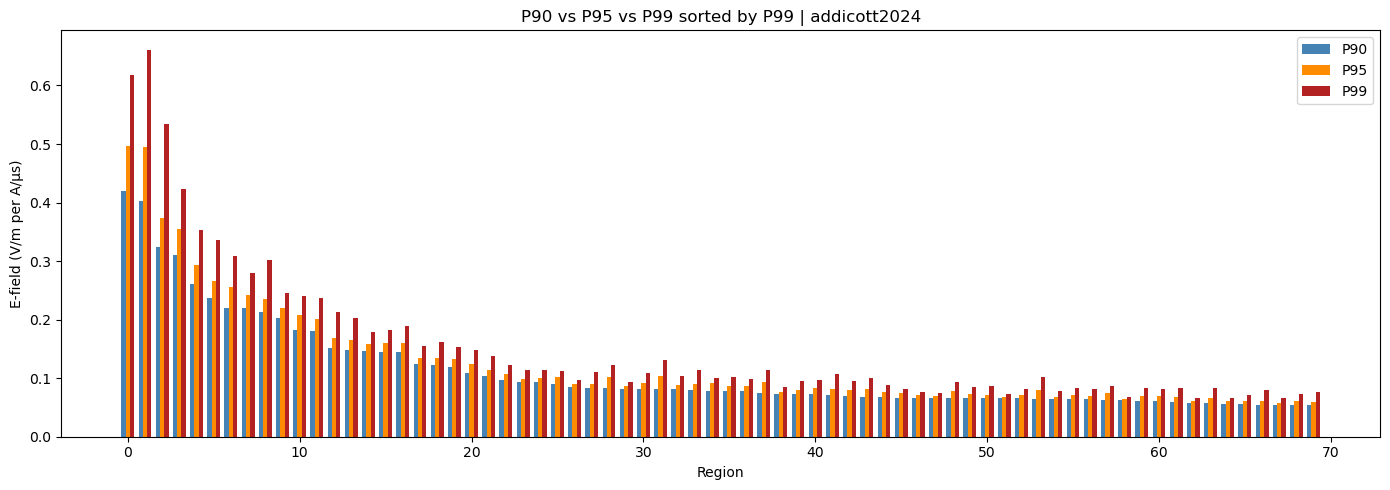

In [43]:
all_p90 = dict(p.rank_regions(n="all", metric="percentile", percentile=90))
all_p95 = dict(p.rank_regions(n="all", metric="percentile", percentile=95))
all_p99 = dict(p.rank_regions(n="all", metric="percentile", percentile=99))

# ordre défini par P99 décroissant — top 10
ordered_ids = sorted(all_p90, key=lambda r: all_p90[r], reverse=True)[:70]

# labels anatomiques
labels = p.get_labels_for_regions(ordered_ids)

x     = np.arange(len(ordered_ids))
width = 0.25

p90s = [all_p90.get(r, 0) for r in ordered_ids]
p95s = [all_p95.get(r, 0) for r in ordered_ids]
p99s = [all_p99.get(r, 0) for r in ordered_ids]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, p90s, width, label="P90", color="steelblue")
ax.bar(x,         p95s, width, label="P95", color="darkorange")
ax.bar(x + width, p99s, width, label="P99", color="firebrick")
if len(x) <= 50:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Region")
ax.set_ylabel("E-field (V/m per A/µs)")
ax.set_title(f"P90 vs P95 vs P99 sorted by P99 | {study_id}")
ax.legend()
plt.tight_layout()
plt.show()

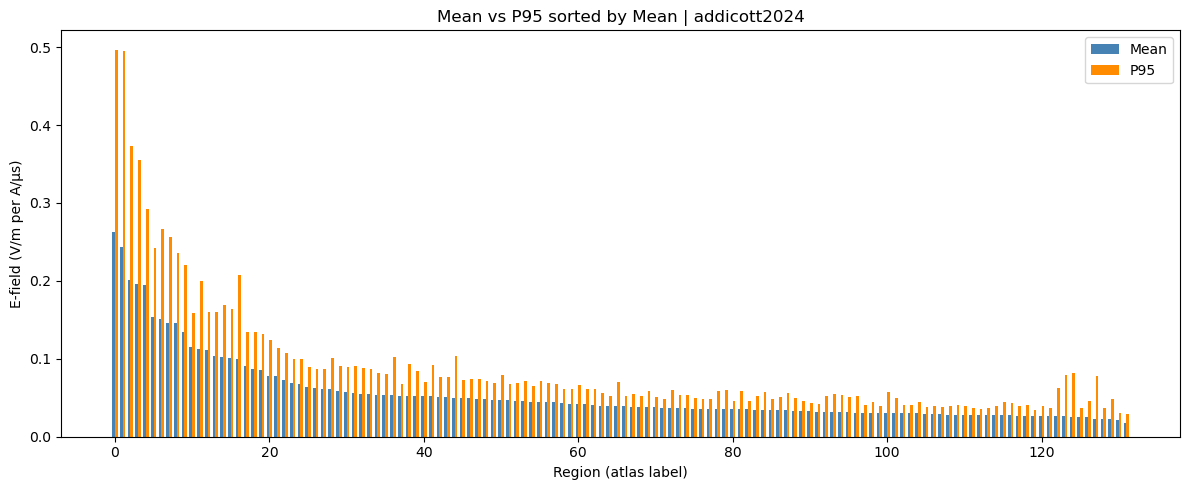

In [32]:
# ── Cellule 4 — Mean vs P95 sorted by Mean ───────────────────────────────────
percentile = 95
all_mean = dict(p.rank_regions(n="all", metric="mean"))
all_p95  = dict(p.rank_regions(n="all", metric="percentile", percentile=percentile))

# ordre défini par la moyenne décroissante — top 10
ordered_labels = sorted(all_mean, key=lambda r: all_mean[r], reverse=True)#[:50]

# labels anatomiques
labels = p.get_labels_for_regions(ordered_labels)

x     = np.arange(len(ordered_labels))
width = 0.35

means = [all_mean.get(r, 0) for r in ordered_labels]
p95s  = [all_p95.get(r, 0)  for r in ordered_labels]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, means, width, label="Mean", color="steelblue")
ax.bar(x + width/2, p95s,  width, label=f"P{percentile}",  color="darkorange")
if len(ordered_labels)<=50:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Region (atlas label)")
ax.set_ylabel("E-field (V/m per A/µs)")
ax.set_title(f"Mean vs P{percentile} sorted by Mean | {study_id}")
ax.legend()
plt.tight_layout()
plt.show()

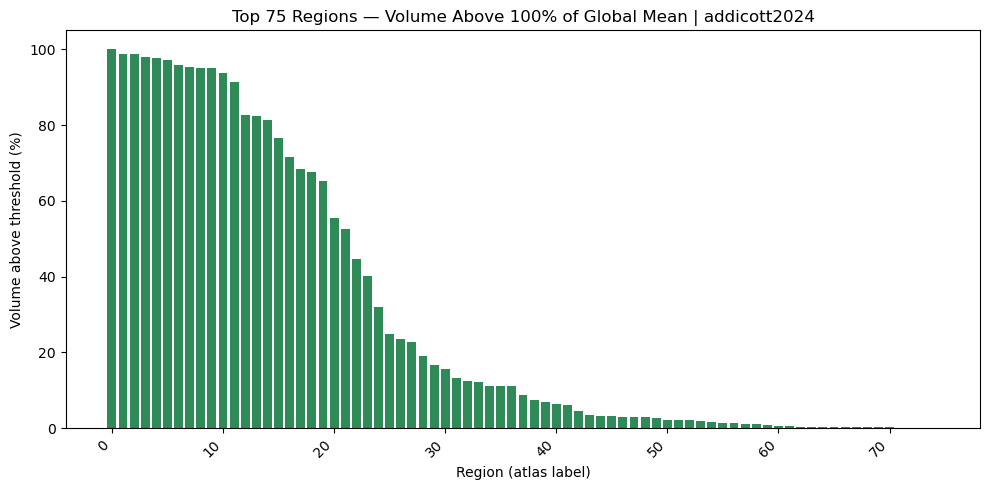

In [41]:
# ── Cellule 6 — Fraction of volume above threshold ────────────────────────────
n = 75
threshold_pct=100

top = p.rank_regions(n=n, metric="above_threshold", threshold_pct=threshold_pct)
region_ids = [r[0] for r in top]
values     = [r[1] for r in top]
labels     = p.get_labels_for_regions(region_ids)
if n >= 50:
    labels = np.arange(n)

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="seagreen")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Region (atlas label)")
plt.ylabel("Volume above threshold (%)")
plt.title(f"Top {n} Regions — Volume Above {threshold_pct}% of Global Mean | {study_id}")
plt.tight_layout()
plt.show()

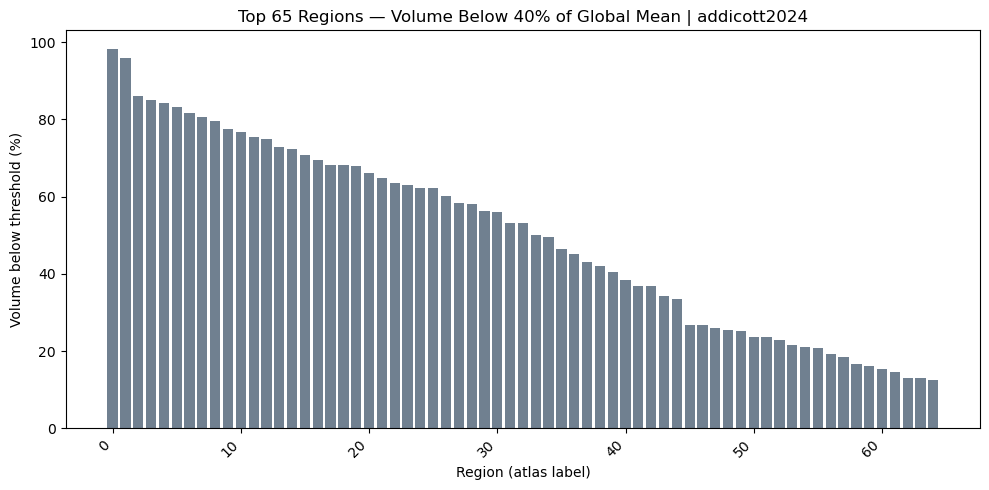

In [ ]:
# ── Cellule 7 — Fraction of volume below threshold ────────────────────────────
n=65
threshold_pct=40

top = p.rank_regions(n=n, metric="below_threshold", threshold_pct=threshold_pct, ascending=False)
region_ids = [r[0] for r in top]
values     = [r[1] for r in top]
labels     = p.get_labels_for_regions(region_ids)
if n >= 50:
    labels = np.arange(n)
    
plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="slategray")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Region (atlas label)")
plt.ylabel("Volume below threshold (%)")
plt.title(f"Top {n} Regions — Volume Below {threshold_pct}% of Global Mean | {study_id}")
plt.tight_layout()
plt.show()

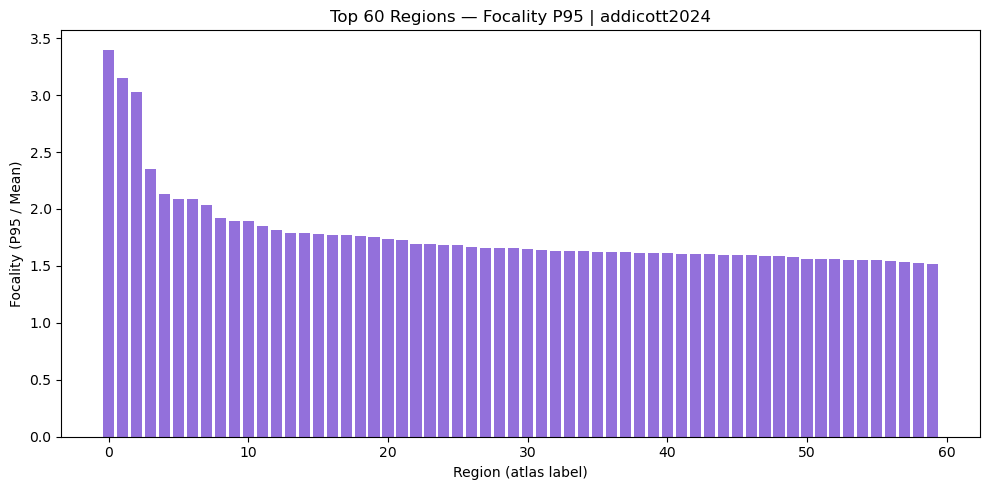

In [ ]:
# ── Cellule — Focality (P95/Mean ratio) ──────────────────────────────────────
n          = 60
percentile = 95
top        = p.rank_regions(n=n, metric="focality", percentile=percentile)
region_ids = [r[0] for r in top]
values     = [r[1] for r in top]
labels     = p.get_labels_for_regions(region_ids)

n_label = "All" if n == "all" else n
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(np.arange(n), values, color="mediumpurple")
if n <= 50:
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Region (atlas label)")
ax.set_ylabel(f"Focality (P{percentile} / Mean)")
ax.set_title(f"Top {n_label} Regions — Focality P{percentile} | {study_id}")
plt.tight_layout()
plt.show()